# Imports and Reading data

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

In [23]:
df = pd.read_csv('STO-const_decay.csv')

# Data understanding

In [24]:
df.shape

# 10000 rows and 5 columns as expected

(10000, 5)

In [ ]:
df.head(5)

,optimizer_gain,dither_amplitude,dither_frequency,converged,convergence_time
0,0.001795,0.409215,0.762317,0,NaN
1,0.001567,0.457554,0.652944,0,NaN
2,0.082227,0.146464,0.618753,0,NaN
3,0.087334,0.482795,0.463045,0,NaN
4,0.039862,0.479012,0.594150,1,11.82


In [26]:
df.dtypes

optimizer_gain      float64
dither_amplitude    float64
dither_frequency    float64
converged             int64
convergence_time    float64
dtype: object

# Data preparation

In [ ]:
df.isna().sum()

# only the convergence_time has duplicated values(2843) so we do not need to drop any rows

optimizer_gain         0
dither_amplitude       0
dither_frequency       0
converged              0
convergence_time    2843
dtype: int64

# Feature understanding

Text(0, 0.5, 'Counts')

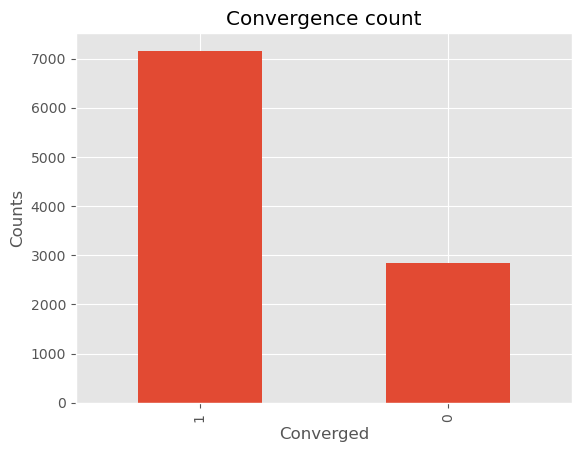

In [ ]:
cv = df['converged'].value_counts().head(10).plot(kind = 'bar', title = 'Convergence count')

cv.set_xlabel('Converged')
cv.set_ylabel('Counts')

# More than 70% converged. I think this is a healthy spread as we care more about the converged combinations

Text(0, 0.5, 'Frequency')

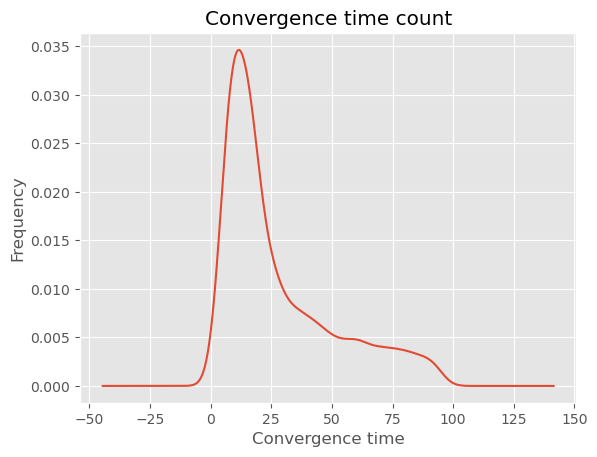

In [29]:
ct = df['convergence_time'].plot(kind = 'kde',
                title = 'Convergence time count')
ct.set_xlabel('Convergence time')
ct.set_ylabel('Frequency')

# Many combinations lead to convergence time < 12.5 seconds, which is really impressive

In [30]:
sum(df['convergence_time'] < 10)

# There are 1560 out of 10000 combinations that has the convergence_time < 10, which is extremely good

1560

In [31]:
sum(df['convergence_time'] < 5)

# 259 combinations have convergence time < 5. I see potential.


259

# Feature relationships

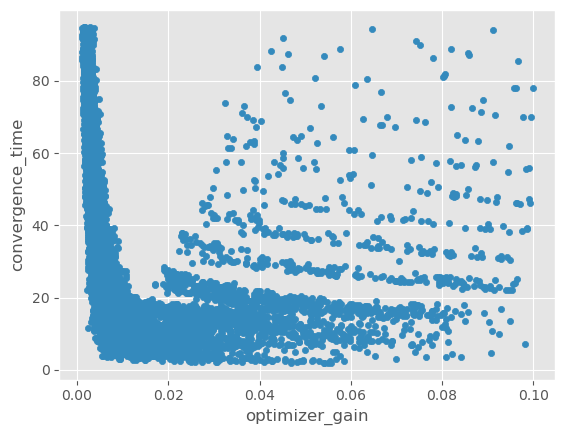

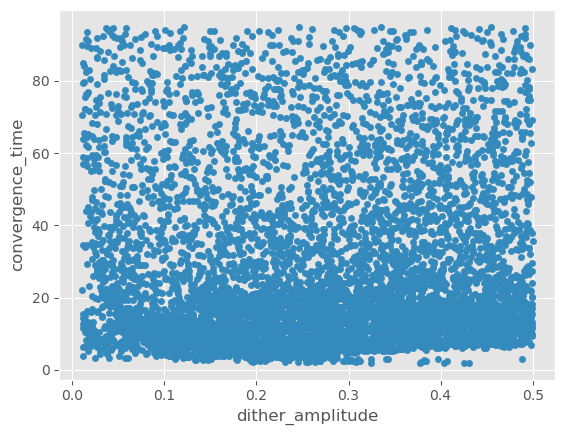

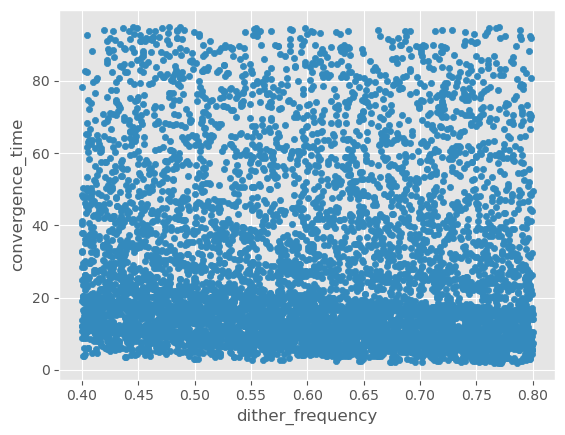

In [ ]:
for i in range (df.shape[1] - 2):
    df.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()


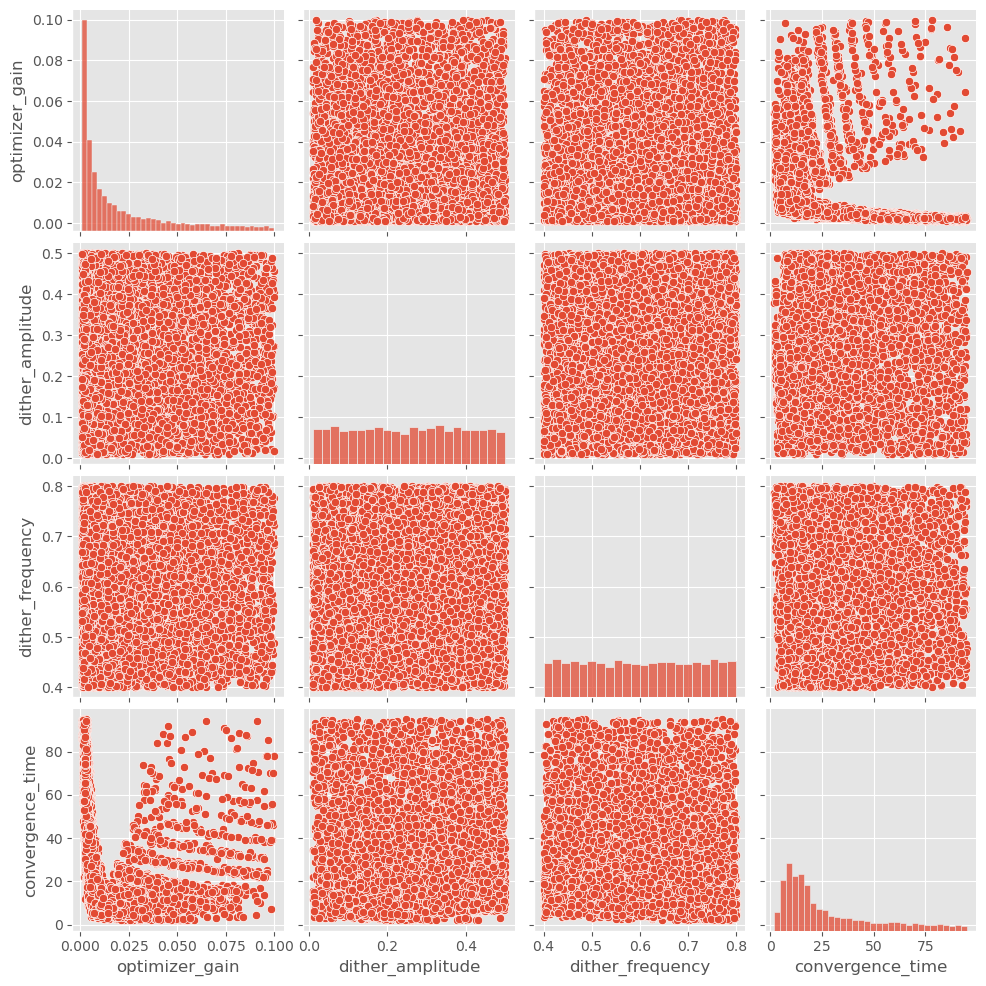

In [ ]:
sns.pairplot(df,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()


<Axes: >

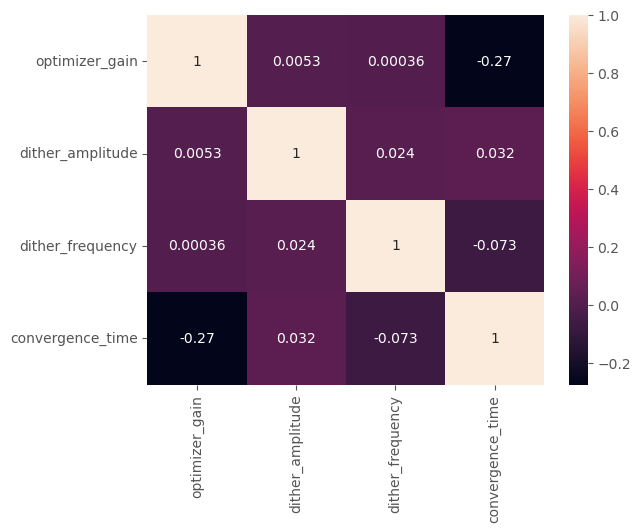

In [ ]:
sns.heatmap(df.drop(columns = 'converged').corr(), annot = True)


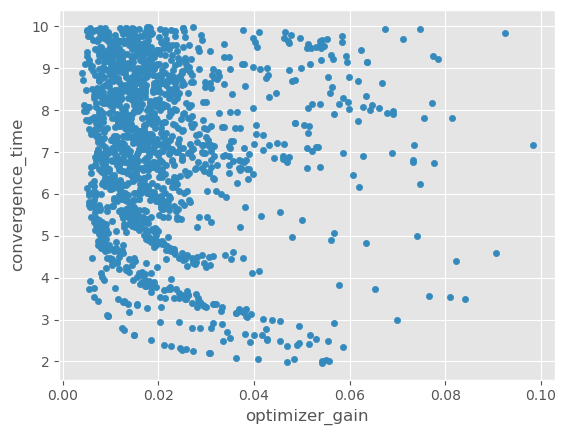

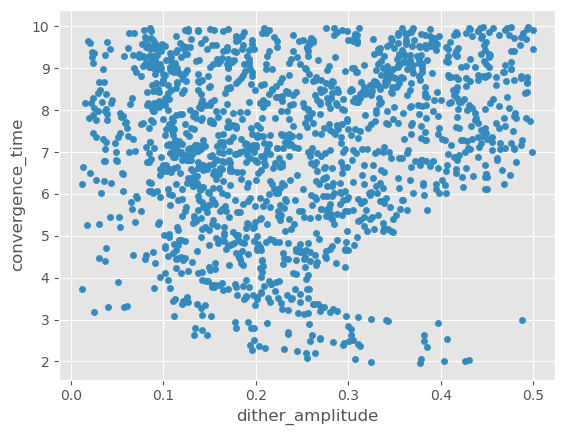

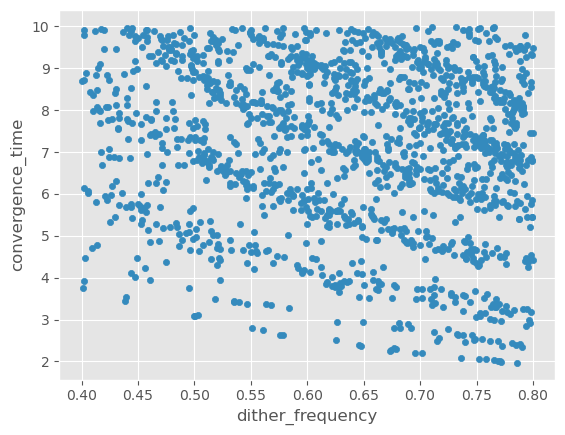

In [ ]:
dfcut = df[df['convergence_time'] < 10]
for i in range (dfcut.shape[1] - 2):
    dfcut.plot(kind = 'scatter',
            x = i,
            y = 'convergence_time')
    plt.show()


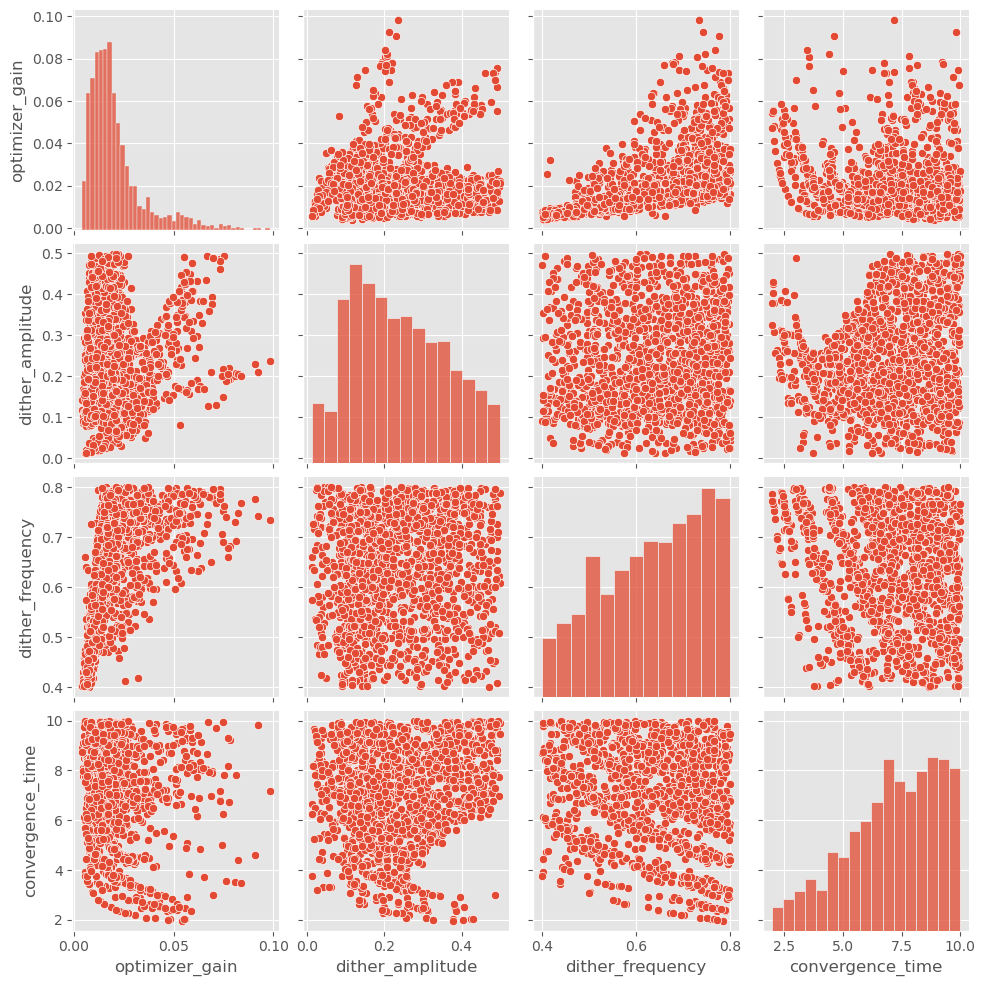

In [ ]:
sns.pairplot(dfcut,
             vars = ['optimizer_gain','dither_amplitude','dither_frequency', 'convergence_time'])
plt.show()


<Axes: >

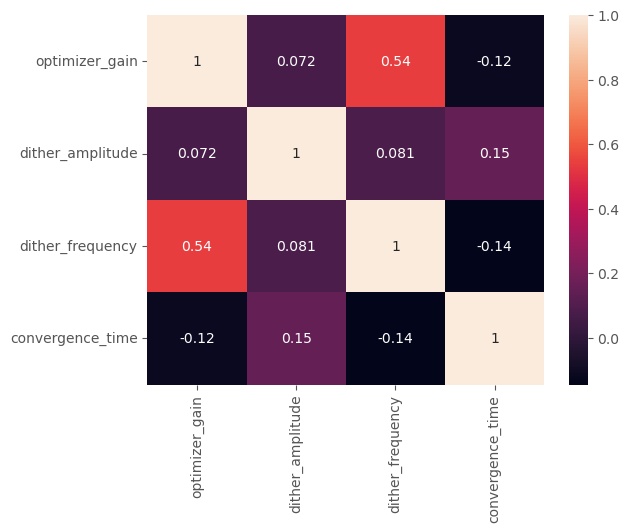

In [ ]:
sns.heatmap(dfcut.drop(columns = 'converged').corr(), annot = True)


# Modelling: Classification

In [38]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score



In [39]:
# Create sets 1 for model 1

X11 = df.drop(columns=['convergence_time', 'converged'])
y11 = df['converged']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train11, X_, y_train11, y_ = train_test_split(X11, y11, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv11, X_test11, y_cv11, y_test11 = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [40]:
# Create model 1 for set 1
model11 = Sequential(
    [
        Dense(32, activation='relu', name="L1"),
        Dense(16, activation='relu', name="L2"),
        Dense(1, activation = 'linear', name = "L3")  
    ]
)

Epoch 1/200


188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5920 - val_loss: 0.5704
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5587 - val_loss: 0.5277
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5011 - val_loss: 0.4534
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4292 - val_loss: 0.4652
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3789 - val_loss: 0.3311
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3214 - val_loss: 0.2952
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2888 - val_loss: 0.2557
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2706 - val_loss: 0.3089
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2542 - val_loss: 0.2186
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2365 - val_loss: 0.2177
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2149 - val_loss: 0.2815
Epoch 12/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

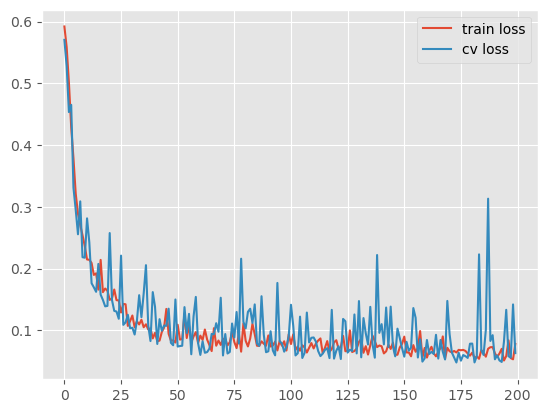

In [41]:
# Train model 1 with sets 1

model11.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history11 = model11.fit(X_train11, 
                     y_train11, 
                     epochs=200, 
                     validation_data=(X_cv11, y_cv11))
plt.plot(history11.history['loss'], label='train loss')
plt.plot(history11.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [ ]:
logits11 = model11.predict(X_cv11)
probs11 = tf.sigmoid(logits11).numpy() # convert logit to probability
y_pred11 = (probs11 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy11 = accuracy_score(y_cv11, y_pred11)
print(f"CV accuracy: {accuracy11:.3f}")

# ~97% accuracy. Nice!

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
CV accuracy: 0.973


In [ ]:
print(confusion_matrix(y_cv11, y_pred11))
print(classification_report(y_cv11, y_pred11))

# The recall for "0" is a bit lower than expected, at only 0.93

[[ 542   38]
 [  17 1403]]
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       580
           1       0.97      0.99      0.98      1420

    accuracy                           0.97      2000
   macro avg       0.97      0.96      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [ ]:
train_logits11 = model11.predict(X_train11)
train_probs11 = tf.sigmoid(train_logits11).numpy()
train_pred11 = (train_probs11 > 0.5).astype(int).flatten()
train_acc11 = accuracy_score(y_train11, train_pred11)
print(f"Train accuracy: {train_acc11:.3f}")

# Both CV and training data achieve ~97%, although train accuracy is a bit higher

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train accuracy: 0.977


I would still try to see if I can achieve even a higher accuracy

In [45]:
# Adding more features
df['log10gain'] = np.log10(df['optimizer_gain'])
df['sinfre'] = np.sin(df['dither_frequency'])
df['product'] = df['optimizer_gain'] * df['dither_amplitude'] * df['sinfre']

In [46]:
# Create set 2 for model 1

X12 = df.drop(columns=['convergence_time', 'converged'])
y12 = df['converged']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train12, X_, y_train12, y_ = train_test_split(X12, y12, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv12, X_test12, y_cv12, y_test12 = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [47]:
# Create model 1 for set 2
model12 = Sequential(
    [
        Dense(32, activation='relu', name="L1"),
        Dense(16, activation='relu', name="L2"),
        Dense(1, activation = 'linear', name = "L3")  
    ]
)

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.5859 - val_loss: 0.5537
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4144 - val_loss: 0.3416
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2364 - val_loss: 0.1935
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1903 - val_loss: 0.1726
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1743 - val_loss: 0.1605
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1823 - val_loss: 0.2356
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1621 - val_loss: 0.1660
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1722 - val_loss: 0.1428
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1586 - val_loss: 0.2724
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1548 - val_loss: 0.1260
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1479 - val_loss: 0.1902
Epoch 12/200
188/188 ━━━━━━━━━━━━━━━━━━━━

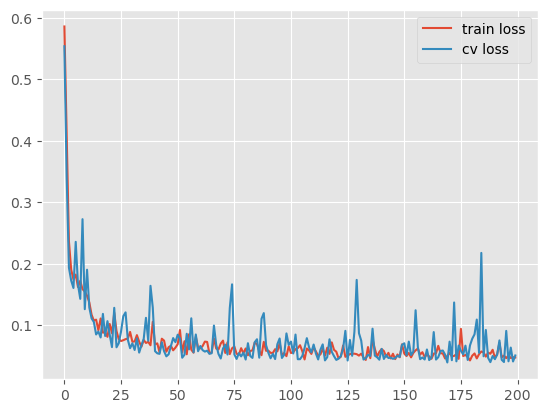

In [48]:
# Train model 1 with set 2

model12.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history12 = model12.fit(X_train12, 
                     y_train12, 
                     epochs=200, 
                     validation_data=(X_cv12, y_cv12))
plt.plot(history12.history['loss'], label='train loss')
plt.plot(history12.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [49]:
logits12 = model12.predict(X_cv12)
probs12 = tf.sigmoid(logits12).numpy() # convert logit to probability
y_pred12 = (probs12 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy12 = accuracy_score(y_cv12, y_pred12)
print(f"CV accuracy: {accuracy12:.3f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
CV accuracy: 0.981


In [50]:
print(confusion_matrix(y_cv12, y_pred12))
print(classification_report(y_cv12, y_pred12))

[[ 546   34]
 [   5 1415]]
              precision    recall  f1-score   support

           0       0.99      0.94      0.97       580
           1       0.98      1.00      0.99      1420

    accuracy                           0.98      2000
   macro avg       0.98      0.97      0.98      2000
weighted avg       0.98      0.98      0.98      2000



In [51]:
train_logits12 = model12.predict(X_train12)
train_probs12 = tf.sigmoid(train_logits12).numpy()
train_pred12 = (train_probs12 > 0.5).astype(int).flatten()
train_acc12 = accuracy_score(y_train12, train_pred12)
print(f"Train accuracy: {train_acc12:.3f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Train accuracy: 0.981


The accuracy actually improved to 98%. I would push a bit further cause why not, I have the code here already.

In [52]:
# Create sets 1 for model 2

X21 = df.drop(columns=['convergence_time', 'converged'])
y21 = df['converged']

# Get 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train21, X_, y_train21, y_ = train_test_split(X21, y21, test_size=0.40, random_state=1)

# Split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv21, X_test21, y_cv21, y_test21 = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete temporary variables
del X_, y_

In [53]:
# Create model 2 for set 1
model21 = Sequential(
    [
        Dense(64, activation='relu', name="L1"),
        Dense(32, activation='relu', name="L2"),
        Dense(16, activation='relu', name="L3"),
        Dense(1, activation = 'linear', name = "L4")  
    ]
)

Epoch 1/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5341 - val_loss: 0.3846
Epoch 2/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3042 - val_loss: 0.2397
Epoch 3/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1628 - val_loss: 0.2186
Epoch 4/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1458 - val_loss: 0.1006
Epoch 5/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1308 - val_loss: 0.0868
Epoch 6/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1262 - val_loss: 0.0831
Epoch 7/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0931 - val_loss: 0.0708
Epoch 8/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1375 - val_loss: 0.1629
Epoch 9/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1112 - val_loss: 0.0900
Epoch 10/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0910 - val_loss: 0.0676
Epoch 11/200
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0855 - val_loss: 0.0837
Epoch 12/200
188/188 ━━━━━━━━━━━━━━━━━━━━

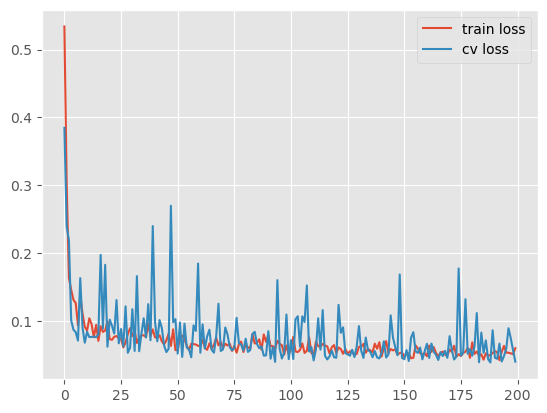

In [54]:
# Train model 2 with set 1

model21.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
history21 = model21.fit(X_train21, 
                     y_train21, 
                     epochs=200, 
                     validation_data=(X_cv21, y_cv21))
plt.plot(history21.history['loss'], label='train loss')
plt.plot(history21.history['val_loss'], label='cv loss')
plt.legend()
plt.show()

In [55]:
logits21 = model21.predict(X_cv21)
probs21 = tf.sigmoid(logits21).numpy() # convert logit to probability
y_pred21 = (probs21 > 0.5).astype(int).flatten() # threshold at 0.5, flatten to 1D
accuracy21 = accuracy_score(y_cv21, y_pred21)
print(f"CV accuracy: {accuracy21:.3f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
CV accuracy: 0.984


In [56]:
print(confusion_matrix(y_cv21, y_pred21))
print(classification_report(y_cv21, y_pred21))


[[ 567   13]
 [  19 1401]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       580
           1       0.99      0.99      0.99      1420

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



In [59]:
train_logits21 = model21.predict(X_train21)
train_probs21 = tf.sigmoid(train_logits21).numpy()
train_pred21 = (train_probs21 > 0.5).astype(int).flatten()
train_acc21 = accuracy_score(y_train21, train_pred21)
print(f"Train accuracy: {train_acc21:.3f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step
Train accuracy: 0.989


It seems like it does improve. I think there is still room for improvement, but we would have to analyse the wrong predictions first.

In [57]:
# Find where the false positives are
false_positive11 = (y_pred11 == 1) & (y_cv11 == 0)
X_cv11_df = pd.DataFrame(X_cv11, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv11_df[false_positive11].describe())

false_positive12 = (y_pred12 == 1) & (y_cv12 == 0)
X_cv12_df = pd.DataFrame(X_cv12, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv12_df[false_positive12].describe())

false_positive21 = (y_pred21 == 1) & (y_cv21 == 0)
X_cv21_df = pd.DataFrame(X_cv21, columns=['optimizer_gain', 
                                          'dither_amplitude', 
                                          'dither_frequency'])
print(X_cv21_df[false_positive21].describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       38.000000         38.000000         38.000000
mean         0.016755          0.200577          0.597107
std          0.020672          0.166087          0.132234
min          0.001221          0.010113          0.405948
25%          0.002503          0.032515          0.485158
50%          0.007677          0.176292          0.566619
75%          0.024171          0.318159          0.743723
max          0.079177          0.491704          0.799936
       optimizer_gain  dither_amplitude  dither_frequency
count       34.000000         34.000000         34.000000
mean         0.025495          0.168871          0.559511
std          0.023205          0.126310          0.123700
min          0.001302          0.010113          0.400028
25%          0.002331          0.069437          0.467144
50%          0.023982          0.166717          0.524551
75%          0.044745          0.232040          0.654967
max          0

In [58]:
fp11 = X_cv11_df[false_positive11]
fp12 = X_cv12_df[false_positive12]
fp21 = X_cv21_df[false_positive21]

fp = pd.concat([fp11, fp12, fp21], ignore_index=True)
print(fp.describe())

       optimizer_gain  dither_amplitude  dither_frequency
count       85.000000         85.000000         85.000000
mean         0.022547          0.182538          0.566432
std          0.021869          0.142131          0.128433
min          0.001221          0.010113          0.400028
25%          0.002554          0.055494          0.464991
50%          0.016588          0.170726          0.535254
75%          0.033850          0.287550          0.660499
max          0.079177          0.496535          0.799936
